In [7]:
from vnstock_forecast.data.query import query_latest, query_ohlcv_grouped
from vnstock_forecast.utils import time_utils

In [8]:
data = query_ohlcv_grouped(symbols=["VHM", "SHB"], from_ts=time_utils.time_to_timestamp("01-09-2025"), to_ts=time_utils.time_to_timestamp("05-03-2026"), resolutions=["D"])

In [9]:
from vnstock_forecast.backtest import BacktestEngine
from vnstock_forecast.backtest.examples import SMABot, BuyAndHoldBot
engine = BacktestEngine(initial_cash=100_000_000)
report = engine.run(bot=BuyAndHoldBot(), data=data["D"], start="2025-05-01", end="2026-03-05")
report.print_summary()

  BACKTEST REPORT: BuyAndHold
  Symbols:        SHB, VHM
  Period:         2025-05-09 → 2026-03-05
  Commission:     0.15%
------------------------------------------------------------
  Initial Cash:       100,000,000
  Final Equity:       141,675,917
  Total PnL:           42,023,848
  Total Return:            41.68%
------------------------------------------------------------
  Trades:                       0
  Wins:                         0
  Losses:                       0
  Win Rate:                  0.0%
  Avg Win:                  0.00%
  Avg Loss:                 0.00%
  R:R Ratio:                  inf
  Max Drawdown:            25.07%
------------------------------------------------------------
  Close Reasons:  {'end_of_data': 2}


In [10]:
report.trade_history()

,id,symbol,entry_time,exit_time,entry_price,exit_price,quantity,stop_loss,take_profit,pnl,pnl_pct,close_reason
0,4c77a9b9,SHB,2025-05-12,2026-03-05,11211.65055,15250.0,4236,None,None,17106448.0,36.02,end_of_data
1,00adc899,VHM,2025-05-12,2026-03-05,62300.00000,95000.0,762,None,None,24917400.0,52.49,end_of_data


In [11]:
report.event_log()

,timestamp,action,symbol,price,quantity,position_id,equity,reason
0,2025-05-12,buy,SHB,11211.65055,4236,4c77a9b9,9.992876e+07,Buy and Hold
1,2025-05-12,buy,VHM,62300.00000,762,00adc899,9.985755e+07,Buy and Hold
2,2026-03-05,end_of_data,SHB,15250.00000,4236,4c77a9b9,1.417845e+08,Đóng cuối kỳ backtest
3,2026-03-05,end_of_data,VHM,95000.00000,762,00adc899,1.416759e+08,Đóng cuối kỳ backtest


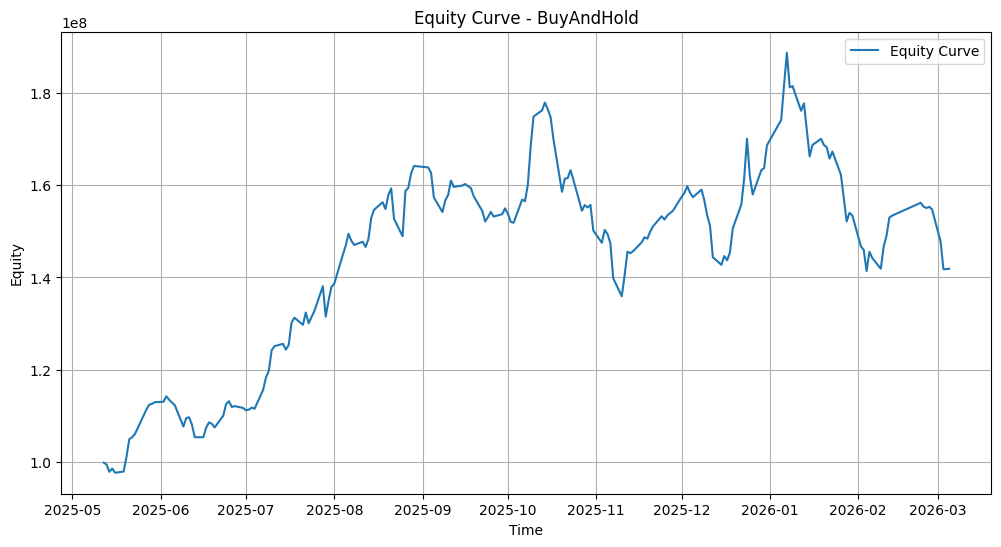

In [12]:
report.plot_equity()